<a href="https://colab.research.google.com/github/espartaca75-prog/Optmizacion_dinamica_discreta/blob/main/07_COD_programaci%C3%B3n_din%C3%A1mica_Ejemplo_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejemplo 7

---



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [2]:
# --- 1. CONFIGURACIÓN DEL PROBLEMA ---
T = 15             # Horizonte de planificación (años)
x0 = 10.0          # Posicionamiento inicial (marca poco conocida)
rho = 5.0          # Rentabilidad marginal de la fama
theta = 0.7        # Tasa de retención (el olvido es 0,3 por ende: 1 - 0.3 = 0.7)
beta = 0.9         # Factor de descuento (paciencia)
A = 15.0           # Valor de legado terminal por unidad de fama

# Diccionarios para almacenar funciones descubiertas
valor_funciones = {}
politicas_descubiertas = {}

In [3]:
# --- 2. FASE DE DESCUBRIMIENTO: INDUCCIÓN HACIA ATRÁS ---
# Definimos la condición terminal en T+1
valor_funciones[T + 1] = lambda x: A * x

print("Iniciando Fase de Descubrimiento...")
for t in range(T, -1, -1):
    def objetivo_negativo(c, x_actual, V_futura):
        # f(x, c) = rho * x - c^2 (Utilidad inmediata)
        utilidad_hoy = rho * x_actual - c**2
        # x_{t+1} = theta * x_t + c (Dinámica del sistema)
        x_siguiente = theta * x_actual + c
        # Maximizar f + beta * V_futura
        return -(utilidad_hoy + beta * V_futura(x_siguiente))

    # Optimizamos para un x de referencia para extraer el monto óptimo (ct*)
    # En este modelo lineal-cuadrático, c* es independiente de x
    res = minimize_scalar(objetivo_negativo, bounds=(0, 100), args=(1.0, valor_funciones[t+1]), method='bounded')

    # Almacenamos el monto de inversión descubierto
    politicas_descubiertas[t] = res.x

    # Actualizamos la función de valor para el periodo anterior (t-1)
    # W_t(x) = f(x, c*) + beta * W_{t+1}(g(x, c*))
    valor_funciones[t] = lambda x, t_idx=t: -objetivo_negativo(politicas_descubiertas[t_idx], x, valor_funciones[t_idx+1])
    print(f"Etapa t={t}: Inversión Óptima Descubierta c* = {politicas_descubiertas[t]:.4f}")

Iniciando Fase de Descubrimiento...
Etapa t=15: Inversión Óptima Descubierta c* = 6.7500
Etapa t=14: Inversión Óptima Descubierta c* = 6.5025
Etapa t=13: Inversión Óptima Descubierta c* = 6.3466
Etapa t=12: Inversión Óptima Descubierta c* = 6.2483
Etapa t=11: Inversión Óptima Descubierta c* = 6.1865
Etapa t=10: Inversión Óptima Descubierta c* = 6.1475
Etapa t=9: Inversión Óptima Descubierta c* = 6.1229
Etapa t=8: Inversión Óptima Descubierta c* = 6.1074
Etapa t=7: Inversión Óptima Descubierta c* = 6.0977
Etapa t=6: Inversión Óptima Descubierta c* = 6.0915
Etapa t=5: Inversión Óptima Descubierta c* = 6.0877
Etapa t=4: Inversión Óptima Descubierta c* = 6.0852
Etapa t=3: Inversión Óptima Descubierta c* = 6.0837
Etapa t=2: Inversión Óptima Descubierta c* = 6.0827
Etapa t=1: Inversión Óptima Descubierta c* = 6.0821
Etapa t=0: Inversión Óptima Descubierta c* = 6.0817


In [4]:
# --- 3. FASE DE EJECUCIÓN: TRAYECTORIA ÓPTIMA  ---
x_hist = [x0]
c_hist = []

for t in range(T + 1):
    c_t = politicas_descubiertas[t]
    c_hist.append(c_t)
    if t < T:
        x_next = theta * x_hist[-1] + c_t
        x_hist.append(x_next)

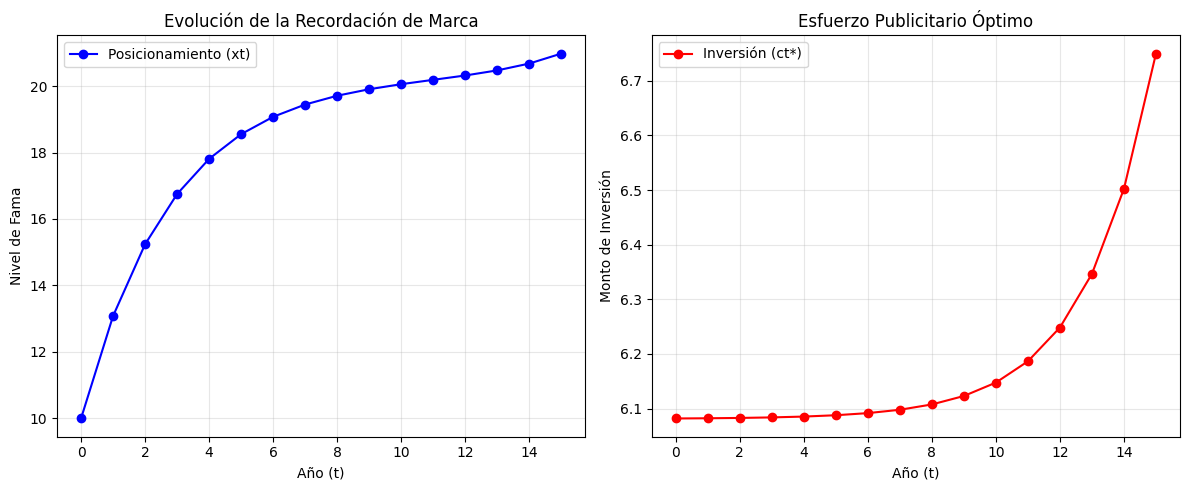

In [5]:
# --- 4. VISUALIZACIÓN DE RESULTADOS ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(T + 1), x_hist, 'bo-', label='Posicionamiento (xt)')
plt.title('Evolución de la Recordación de Marca')
plt.xlabel('Año (t)'); plt.ylabel('Nivel de Fama')
plt.grid(True, alpha=0.3); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(T + 1), c_hist, 'ro-', label='Inversión (ct*)')
plt.title('Esfuerzo Publicitario Óptimo')
plt.xlabel('Año (t)'); plt.ylabel('Monto de Inversión')
plt.grid(True, alpha=0.3); plt.legend()

plt.tight_layout(); plt.show()


In [6]:
# --- 5. ARMADO DE TABLA DE RESULTADOS  ---
# x_hist ya contiene la evolución desde t=0 hasta t=T (T+1 elementos)
# c_hist contiene los esfuerzos de inversión desde t=0 hasta t=T (T+1 elementos)

# agregamos la funcion de legado
x_T_plus_1 = theta * x_hist[-1] + c_hist[-1]
x_hist.append(x_T_plus_1)

# Preparamos la columna de control, añadiendo un valor nulo para el periodo de legado T+1
c_trayectoria_completa = list(c_hist) + [np.nan]

# Construimos el DataFrame
df_resultados = pd.DataFrame({
    'Periodo (t)': range(T + 2),
    'Stock de Marca (xt)': x_hist,
    'Inversión Publicitaria (ct*)': c_trayectoria_completa
})

# Formateamos la salida
print("\nTABLA DE TRAYECTORIA ÓPTIMA DE POSICIONAMIENTO:")
print(df_resultados.to_string(index=False, na_rep='(Legado)', float_format='%.4f'))

# Verificación de consistencia con el legado final
print(f"\nPosicionamiento final de la marca en T+1: {x_hist[-1]:.4f}")



TABLA DE TRAYECTORIA ÓPTIMA DE POSICIONAMIENTO:
 Periodo (t)  Stock de Marca (xt)  Inversión Publicitaria (ct*)
           0              10.0000                        6.0817
           1              13.0817                        6.0821
           2              15.2393                        6.0827
           3              16.7503                        6.0837
           4              17.8089                        6.0852
           5              18.5514                        6.0877
           6              19.0737                        6.0915
           7              19.4431                        6.0977
           8              19.7079                        6.1074
           9              19.9029                        6.1229
          10              20.0550                        6.1475
          11              20.1859                        6.1865
          12              20.3166                        6.2483
          13              20.4700                      